<a href="https://colab.research.google.com/github/jarrodsb/ETAMU-binary-systems/blob/main/notebooks/RandomForestPrototype/Random_Forest_Prototype.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forest Classifier Toy Model for Classifying Planet Stability in Binary Systems

## Jarrod Bieber
## East Texas A&M University
## Summer 2026
---

## 1. Environment setup

In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as cm
import os

# Install scikit-learn
!pip install scikit-learn

# for importing training data from CSV
from google.colab import drive

# for data exploration
import seaborn as sns

# for building the models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler # For scaling the numerical features -> (0 to 1)
from sklearn.ensemble import RandomForestClassifier

# for evaluating model performance
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

## Import Data
---

## 2. Import CSV file and convert into a pandas DataFrame

We import a CSV file containing thousands of simulations of a single-planet s-type binary system into our notebook. We convert our imported CSV with all of the extracted features and the determined stability labels into a pandas DataFrame. This DataFrame will be the input for training our machine-learning model.

In [ ]:
drive.mount('/content/drive')

# Please replace 'your_filename.csv' with the actual name of your CSV file.
# Assuming the file is in the same directory as the notebook, the path might be:
# file_path = '/content/drive/MyDrive/your_filename.csv'
# If the file is in a subdirectory, adjust the path accordingly, e.g., '/content/drive/MyDrive/data/your_filename.csv'

# Example placeholder for the filename
csv_filename = "s_type_stability_data_10000.csv" # Replace with your actual CSV file name

# Assuming the CSV file is in the same directory as the notebook, adjust the path as needed
file_path = f'/content/drive/MyDrive/East Texas A&M/ETAMU Research Assistant/Random Forest Prototype/{csv_filename}'

try:
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)
    print(f"Successfully loaded '{csv_filename}' into DataFrame.")
    print("First 5 rows of the DataFrame:")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure the filename and path are correct and that Google Drive is mounted properly.")
except Exception as e:
    print(f"An error occurred while reading the CSV file: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Successfully loaded 's_type_stability_data_10000.csv' into DataFrame.
First 5 rows of the DataFrame:


,mu,e_bin,rho,e_p,inc_p,megno_median,megno_std,e_p_free,e_p_forced,a_p_std,rho_crit_HW99,stable
0,0.565682,0.045941,0.393311,0.279808,4.260847,3.287987,0.705223,0.028304,1.156589,2.649678,0.224473,0
1,0.855790,0.299900,0.368131,0.273853,3.203102,7.651300,2.123393,0.111410,1.091781,53.130552,0.012642,0
2,0.753545,0.444187,0.145958,0.178384,27.574753,4.317005,0.812281,0.044859,1.145639,21.576165,-0.000272,0
3,0.729070,0.083735,0.213910,0.054771,12.232601,5.954520,1.621862,0.101876,1.026467,17.631418,0.145112,0
4,0.766885,0.630550,0.382674,0.006345,20.390009,2.052453,0.025683,0.020346,2.247378,0.145479,-0.047204,0


### Extracted Features:

1.  **`megno_median`**: The median value of the Mean Exponential Growth of Nearby Orbits (MEGNO) chaos indicator over the last 10% of the short integration. MEGNO quantifies the chaoticity of an orbit, with values close to 2 indicating regular motion and larger values indicating chaos.
2.  **`megno_std`**: The standard deviation of the MEGNO values over the last 80% of the integration. This helps to characterize the variability of the chaotic indicator, avoiding initial transients and providing a more robust measure of the system's long-term behavior.
3.  **`mu`**: The binary mass ratio, $m_B / (m_A + m_B)$. This is a fundamental system parameter.
4.  **`e_bin`**: The eccentricity of the binary orbit. This affects the strength of gravitational perturbations on the planet.
5.  **`rho`**: The ratio of the planetary semimajor axis to the binary semimajor axis, $a_p / a_{bin}$. This indicates how close the planet orbits to the binary.
6.  **`e_p_free`**: The free eccentricity of the planet. This is the component of the eccentricity that is not forced by the binary's gravitational influence. It represents the intrinsic eccentricity of the planet's orbit.
7.  **`e_p_forced`**: The forced eccentricity amplitude of the planet. This is the eccentricity induced on the planet's orbit by the time-averaged gravitational field of the binary. It's calculated from the magnitude of the time-averaged eccentricity vector.
8.  **`inc_p`**: The initial planetary inclination relative to the binary orbital plane. High inclinations can lead to Kozai-Lidov cycles, which can drive eccentricity to high values.
9.  **`a_p_std`**: The standard deviation of the planetary semimajor axis over the short integration, normalized by its initial value. This serves as a proxy for orbital energy diffusion; larger values indicate less stable orbits.
10. **`rho_crit_HW99`**: The analytical critical semimajor axis ratio derived from Holman & Wiegert (1999) for S-type planets, given the binary's mass ratio and eccentricity. This provides a theoretical baseline for the stability limit against which the ML model can be compared.

*Note: This set of features is a physically-adapted analogue of SPOCK's original features (Tamayo et al. 2020), tailored for S-type stability in binary systems where secular/Kozai perturbations are dominant, rather than planet-planet resonances.*

## 3. Data exploration

### Inspecting the DataFrame

In [ ]:
print(f"Total stable systems: {df['stable'].sum()} out of {len(df)}")
print(f"Total unstable systems: {len(df) - df['stable'].sum()} out of {len(df)}")

Total stable systems: 153 out of 10000
Total unstable systems: 9847 out of 10000


In [ ]:
# Display the first few rows and a statistical summary of the DataFrame
print("DataFrame head:")
display(df.head())

print("\nDataFrame descriptive statistics:")
display(df.describe())

DataFrame head:


,mu,e_bin,rho,e_p,inc_p,megno_median,megno_std,e_p_free,e_p_forced,a_p_std,rho_crit_HW99,stable
0,0.565682,0.045941,0.393311,0.279808,4.260847,3.287987,0.705223,0.028304,1.156589,2.649678,0.224473,0
1,0.855790,0.299900,0.368131,0.273853,3.203102,7.651300,2.123393,0.111410,1.091781,53.130552,0.012642,0
2,0.753545,0.444187,0.145958,0.178384,27.574753,4.317005,0.812281,0.044859,1.145639,21.576165,-0.000272,0
3,0.729070,0.083735,0.213910,0.054771,12.232601,5.954520,1.621862,0.101876,1.026467,17.631418,0.145112,0
4,0.766885,0.630550,0.382674,0.006345,20.390009,2.052453,0.025683,0.020346,2.247378,0.145479,-0.047204,0



DataFrame descriptive statistics:


,mu,e_bin,rho,e_p,inc_p,megno_median,megno_std,e_p_free,e_p_forced,a_p_std,rho_crit_HW99,stable
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.499927,0.350661,0.258295,0.150971,20.059973,15.354738,3.428935,0.792636,1.056386,117.134214,0.118588,0.015300
std,0.229069,0.202057,0.139104,0.086615,11.520337,140.295351,43.720970,1.264321,0.773211,1887.505634,0.106323,0.122749
min,0.100015,0.000003,0.020013,0.000015,0.005628,0.150099,0.000010,0.000873,0.000205,0.000027,-0.087231,0.000000
25%,0.303326,0.177074,0.137296,0.076128,10.066068,2.002863,0.001863,0.029468,0.376670,1.302908,0.037488,0.000000
50%,0.502752,0.347916,0.256881,0.152899,20.108030,2.488988,0.232572,0.185029,1.099349,7.551613,0.107831,0.000000
75%,0.695211,0.526442,0.379251,0.226136,30.099629,8.473869,2.114601,1.152305,1.486906,39.374126,0.190744,0.000000
max,0.899962,0.699990,0.499944,0.299905,39.996620,11221.995822,3857.764393,24.602300,21.931946,116136.624819,0.424929,1.000000


### Class Balance

In [ ]:
# Print the class balance of the 'stable' column
print("Stability class balance:")
display(df['stable'].value_counts())

Stability class balance:


,count
stable,
0,9847
1,153


### Correlation Matrix Heatmap

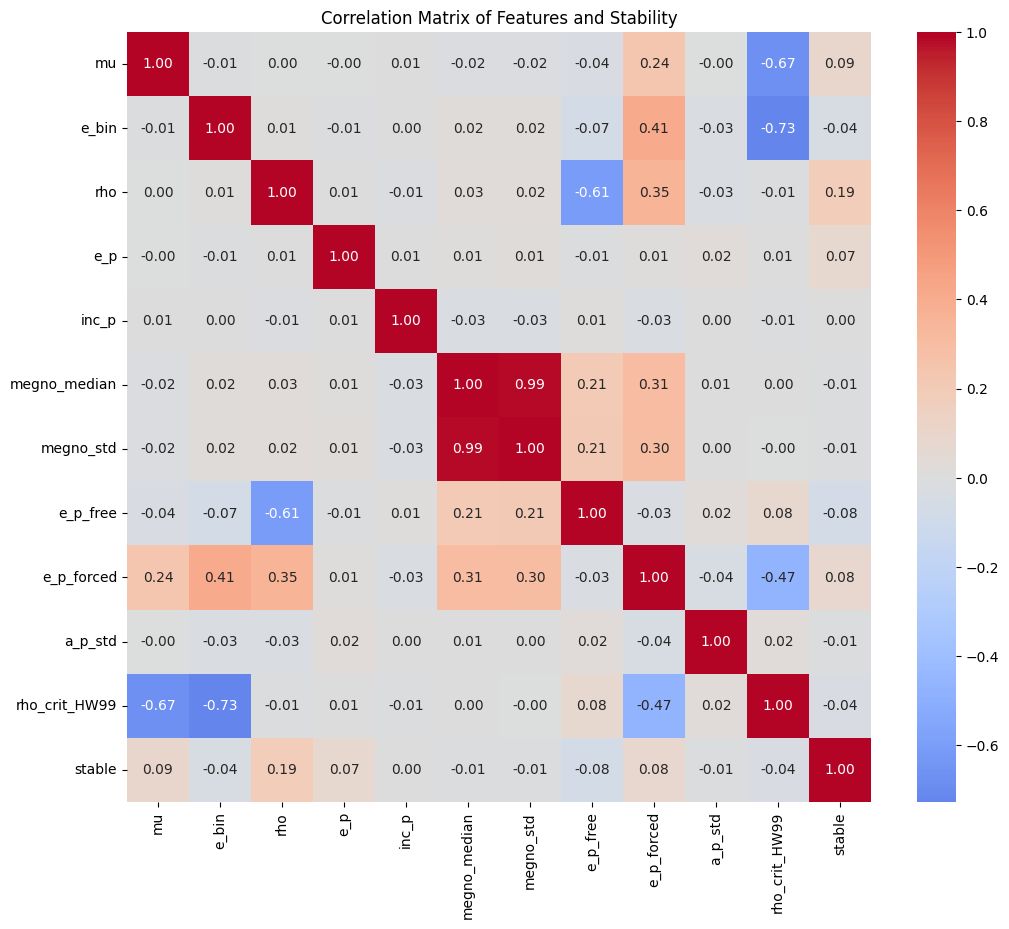

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title('Correlation Matrix of Features and Stability')
plt.show()

## 4. Building the Model
---

### Data Splitting

In [ ]:
# Define features (X) and target (y)
# The feature_columns list should contain the names of the features we want to use for the ML model.
# As per the plan, we will use the 10 features, excluding 'rho_crit_HW99' from X directly
# as it's an analytical baseline we compare against, not a feature for the ML model itself.

feature_columns = [
    'megno_median', 'megno_std', 'e_p_free', 'e_p_forced', 'a_p_std',
    'mu', 'e_bin', 'rho', 'e_p', 'inc_p'
]

X = df[feature_columns]
y = df['stable']

# Encode the target variable ('y')
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split the data into training and testing sets


X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\ny_train class balance:")
display(pd.Series(y_train).value_counts())

print("\ny_test class balance:")
display(pd.Series(y_test).value_counts())

X_train shape: (8000, 10)
X_test shape: (2000, 10)
y_train shape: (8000,)
y_test shape: (2000,)

y_train class balance:


,count
0,7878
1,122



y_test class balance:


,count
0,1969
1,31


### Training a RandomForestClassifier

In [ ]:
# Initialize the Random Forest Classifier
# Using class_weight='balanced' can help mitigate the effects of class imbalance
# by adjusting weights inversely proportional to class frequencies. This is crucial given our imbalanced dataset.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Train the model
rf_model.fit(X_train, y_train)

print("RandomForestClassifier trained successfully.")

RandomForestClassifier trained successfully.


### Reporting Accuracy, AUC, and Feature Importance

Accuracy: 0.9925
AUC: 0.9742

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1969
           1       0.90      0.58      0.71        31

    accuracy                           0.99      2000
   macro avg       0.95      0.79      0.85      2000
weighted avg       0.99      0.99      0.99      2000


Confusion Matrix:


,Predicted Unstable,Predicted Stable
Actual Unstable,1967,2
Actual Stable,13,18


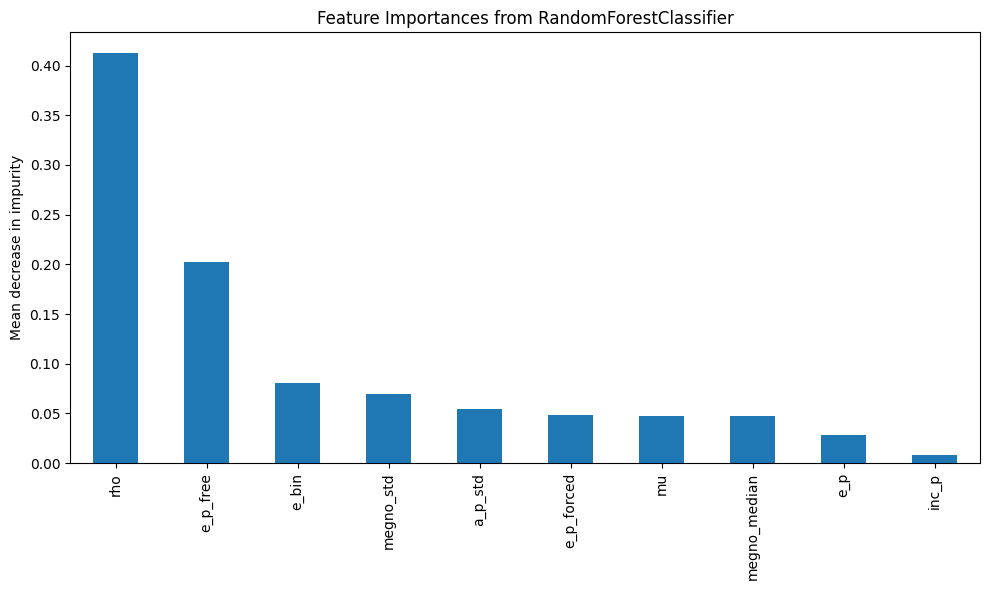

In [ ]:
# Make predictions on the test set
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1] # Probability of the positive class (stable)

# Report Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Report AUC (Area Under the Receiver Operating Characteristic Curve)
# AUC calculation can fail if there's only one class present in y_true or y_score.
# We use a try-except block to handle this gracefully, which is likely given the small number of stable samples.
try:
    auc = roc_auc_score(y_test, y_pred_proba)
    print(f"AUC: {auc:.4f}")
except ValueError as e:
    print(f"Could not calculate AUC: {e}. This is often due to only one class being present in y_test or y_pred_proba for the test set.")
    auc = np.nan # Assign NaN if AUC cannot be calculated

print("\nClassification Report:")
# zero_division=0 to prevent warnings if a class has no predicted samples
print(classification_report(y_test, y_pred, zero_division=0))

print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred), index=['Actual Unstable', 'Actual Stable'], columns=['Predicted Unstable', 'Predicted Stable']))

# Feature Importance Plot
importances = rf_model.feature_importances_
feature_names = X.columns

forest_importances = pd.Series(importances, index=feature_names)

fig, ax = plt.subplots(figsize=(10, 6))
forest_importances.sort_values(ascending=False).plot.bar(ax=ax)
ax.set_title("Feature Importances from RandomForestClassifier")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
plt.show()

### Comparison with `rho_crit_HW99` Analytic Baseline

In [ ]:
# Predict stability based on rho_crit_HW99: stable if rho < rho_crit_HW99
# We need to ensure 'rho_crit_HW99' is available in the test set for comparison.
# X_test_analytic will be the subset of the original DataFrame corresponding to the test set indices.

# First, ensure 'rho_crit_HW99' is in the original df and then extract the test set portion.
# Since 'rho_crit_HW99' is calculated and added to the 'df' DataFrame, we can use df.loc[X_test.index]
# to get the corresponding rows from the original DataFrame.

X_test_full = df.loc[X_test.index]

# Calculate the predicted stability based on the analytic formula:
# If rho (planetary semimajor axis ratio) is less than rho_crit_HW99, it's considered stable (1), otherwise unstable (0).
y_pred_analytic = (X_test_full['rho'] < X_test_full['rho_crit_HW99']).astype(int)

# Evaluate the analytic baseline
accuracy_analytic = accuracy_score(y_test, y_pred_analytic)

# AUC for analytic baseline
try:
    auc_analytic = roc_auc_score(y_test, y_pred_analytic)
    print(f"Analytic Baseline AUC: {auc_analytic:.4f}")
except ValueError as e:
    print(f"Could not calculate Analytic Baseline AUC: {e}. This is often due to only one class being present in y_test.")
    auc_analytic = np.nan # Assign NaN if AUC cannot be calculated

print(f"Analytic Baseline Accuracy: {accuracy_analytic:.4f}")

print("\nAnalytic Baseline Classification Report:")
print(classification_report(y_test, y_pred_analytic, zero_division=0))

print("\nAnalytic Baseline Confusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_analytic), index=['Actual Unstable', 'Actual Stable'], columns=['Predicted Unstable', 'Predicted Stable']))

print("\nSummary Comparison:")
print(f"RandomForest Accuracy: {accuracy:.4f}")
print(f"Analytic Baseline Accuracy: {accuracy_analytic:.4f}")

rf_auc_str = f'{auc:.4f}' if not np.isnan(auc) else 'N/A'
analy_auc_str = f'{auc_analytic:.4f}' if not np.isnan(auc_analytic) else 'N/A'
print(f"RandomForest AUC: {rf_auc_str}")
print(f"Analytic Baseline AUC: {analy_auc_str}")


Analytic Baseline AUC: 0.3852
Analytic Baseline Accuracy: 0.7585

Analytic Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.77      0.86      1969
           1       0.00      0.00      0.00        31

    accuracy                           0.76      2000
   macro avg       0.49      0.39      0.43      2000
weighted avg       0.96      0.76      0.85      2000


Analytic Baseline Confusion Matrix:


,Predicted Unstable,Predicted Stable
Actual Unstable,1517,452
Actual Stable,31,0



Summary Comparison:
RandomForest Accuracy: 0.9925
Analytic Baseline Accuracy: 0.7585
RandomForest AUC: 0.9742
Analytic Baseline AUC: 0.3852
